# Predicting Next-Day Closing Price of Cryptocurrencies using Linear Regression
This Python script implements a standard Linear Regression model to predict the next day's closing price for cryptocurrencies. It loads historical market data, performs feature engineering (e.g., moving averages, daily returns) for each cryptocurrency group, and then trains a single, unified Linear Regression model on the combined, scaled dataset. The model's performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R2), and the trained model and its scaler are saved for future use.


Feature Engineering
Features include:
- Market indicators: `open`, `high`, `low`, `volume`, `market`, `spread`, `close_ratio`
- Technical indicators: `prev_close`, `daily_return`, `ma_3`, `ma_7`, `volume_change`


Overall Linear Regression Model Evaluation:
Mean Absolute Error (MAE): 16.59
Root Mean Squared Error (RMSE): 54.88
R-squared (R2): 0.500


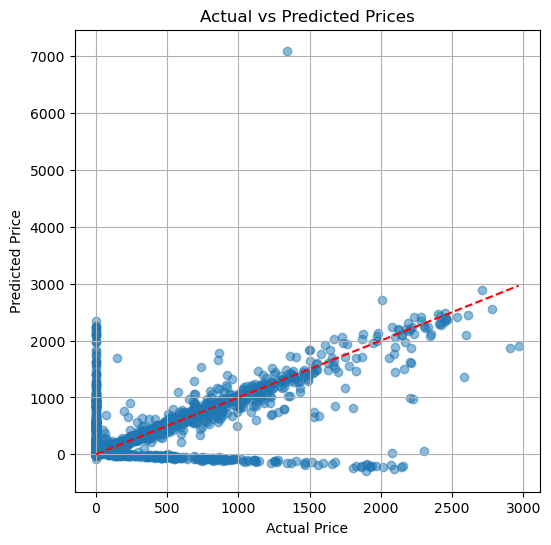


Model Summary: {'Model': 'Linear Regression', 'MAE': 16.58513973595829, 'RMSE': 54.875478319158574, 'R²': 0.5003002761699675}

Model and scaler saved as 'crypto_unified_linear_regression.pkl' and 'crypto_unified_scaler.pkl'.

Sample Predictions from Loaded Model:
[-0.22213415 20.21131427  2.51716605 -9.43587551 35.31741403]


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import joblib

# Load the dataset from GitHub
url = 'https://raw.githubusercontent.com/deysoumyadey/UofT-DSI-Cohort5-ML-T1/main/crypto-markets.csv'
df = pd.read_csv(url)

# Sort the DataFrame first by 'symbol' and then by 'date'
df = df.sort_values(by=['symbol', 'date']).copy()

# Create target: next day's close.
# Use groupby('symbol') to ensure the shift operation is applied independently
df['target'] = df.groupby('symbol')['close'].shift(-1)


# Feature Engineering
# 'prev_close': Previous day's closing price.
df['prev_close'] = df.groupby('symbol')['close'].shift(1)
# 'daily_return': Daily return based on open and close prices.
df['daily_return'] = (df['close'] - df['open']) / df['open']
# 'ma_3': 3-day moving average of the closing price.
df['ma_3'] = df.groupby('symbol')['close'].rolling(3).mean().reset_index(level=0, drop=True)
# 'ma_7': 7-day moving average of the closing price.
df['ma_7'] = df.groupby('symbol')['close'].rolling(7).mean().reset_index(level=0, drop=True)
# 'volume_change': Percentage change in trading volume from the previous day.
df['volume_change'] = df.groupby('symbol')['volume'].pct_change()


# Drop rows with NaN values that resulted from feature engineering
# replace any remaining infinite values (from division by zero in daily_return, etc.)
# with NaN and then drop those rows.
df = df.dropna()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# These are the independent variables that will be used to predict the 'target'.
features = ['open', 'high', 'low', 'volume', 'market', 'spread', 'close_ratio',
            'prev_close', 'daily_return', 'ma_3', 'ma_7', 'volume_change']


# Separate features (X) and target (y) for the entire processed dataset.
X = df[features]
y = df['target']


# Split the data into training and testing sets.
# test_size=0.2 means 20% of the data will be used for testing.
# shuffle=False to preserve the chronological order,
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# preventing features with larger numerical ranges from dominating the model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Initialize and train the Linear Regression model.
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set.
predictions = model.predict(X_test_scaled)

# Evaluate the model's performance using standard regression metrics.
# Mean Absolute Error (MAE): Average of the absolute differences between predictions and actual values.
mae = mean_absolute_error(y_test, predictions)
# Root Mean Squared Error (RMSE): Square root of the average of the squared differences.
rmse = np.sqrt(mean_squared_error(y_test, predictions))
# R-squared (R2): Coefficient of determination
r2 = r2_score(y_test, predictions)

# Print the evaluation metrics for the unified model.
print("Overall Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()


def get_model_summary(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

summary = get_model_summary("Linear Regression", y_test, predictions)
print("\nModel Summary:", summary)


# Save the trained model and the fitted scaler.
joblib.dump(model, 'crypto_unified_linear_regression.pkl')
joblib.dump(scaler, 'crypto_unified_scaler_linear_regression.pkl')

print("\nModel and scaler saved as 'crypto_unified_linear_regression.pkl' and 'crypto_unified_scaler.pkl'.")

# Load the saved model and scaler to verify they work
loaded_model = joblib.load('crypto_unified_linear_regression.pkl')
loaded_scaler = joblib.load('crypto_unified_scaler_linear_regression.pkl')

# Use a few test samples to check predictions from the loaded model
sample_data = X_test.iloc[:5]
scaled_sample = loaded_scaler.transform(sample_data)
sample_predictions = loaded_model.predict(scaled_sample)

print("\nSample Predictions from Loaded Model:")
print(sample_predictions)



